# Clustering Jerarquico - Segmentacion de clientes de gimnasio (2 variables)

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · No Supervisado · Clustering · Jerárquico

---

**Objetivo:** Aplicar clustering jerarquico aglomerativo sobre datos reales del gimnasio usando 2 variables (Antiguedad y Gasto Extra), comparar el efecto de la estandarizacion y perfilar cada segmento.

**Contexto de negocio:** La cadena de gimnasios quiere segmentar socios segun su antiguedad y gasto en extras para disenar ofertas personalizadas. La pregunta: los socios veteranos gastan mas?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, set_link_color_palette
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
np.random.seed(42)

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND    = '#fbfbfb'
PURPLE        = '#7a7bff'   # único color de énfasis / serie única en scatter y líneas (1 por gráfico)
PURPLE_LIGHT  = '#9b9cff'   # EDA de una sola serie (histogramas independientes)
POSITIVE      = '#6b8158'   # exclusivo signo positivo
NEGATIVE      = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR   = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE  = '#8f8c9e'   # líneas de contexto
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ líneas de contexto
INK           = '#111111'
MUTED         = '#707070'

# Paleta categórica para identidad de cluster — validada (ΔE OKLab, simulación CVD) para
# pares adyacentes (barras, líneas, enlaces de dendrograma). En scatter/PCA/t-SNE con 4+ clusters
# el color por sí solo no basta para daltonismo severo: por eso cada cluster lleva también
# una forma de marcador distinta (CLUSTER_MARKERS) — nunca dependas solo del color.
CLUSTER_PALETTE = ['#7a7bff', '#eb6834', '#1baf7a', '#e34948', '#eda100', '#e87ba4', '#008300']
CLUSTER_MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X']

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


## 1. Carga y exploracion del dataset

In [2]:
df = pd.read_excel("gym_clientes.xlsx")

print(f"Dataset: {df.shape[0]} clientes, {df.shape[1]} variables")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nEstadisticas de las 2 variables seleccionadas:")
display(df[["Antiguedad_Meses", "Gasto_Mensual_Extra"]].describe().round(2))

Dataset: 300 clientes, 7 variables

Columnas: ['ID_Cliente', 'Antiguedad_Meses', 'Asistencias_Mes', 'Horas_Pico_Mes', 'Gasto_Mensual_Extra', 'Satisfecho', 'Abandono']

Estadisticas de las 2 variables seleccionadas:


,Antiguedad_Meses,Gasto_Mensual_Extra
count,300.00,300.00
mean,18.88,81.69
std,10.60,30.47
min,1.00,10.00
25%,9.00,61.25
50%,20.00,82.24
75%,28.00,104.11
max,35.00,145.91


## 2. Exploracion visual

Visualizamos la relacion entre ambas variables antes de clusterizar.

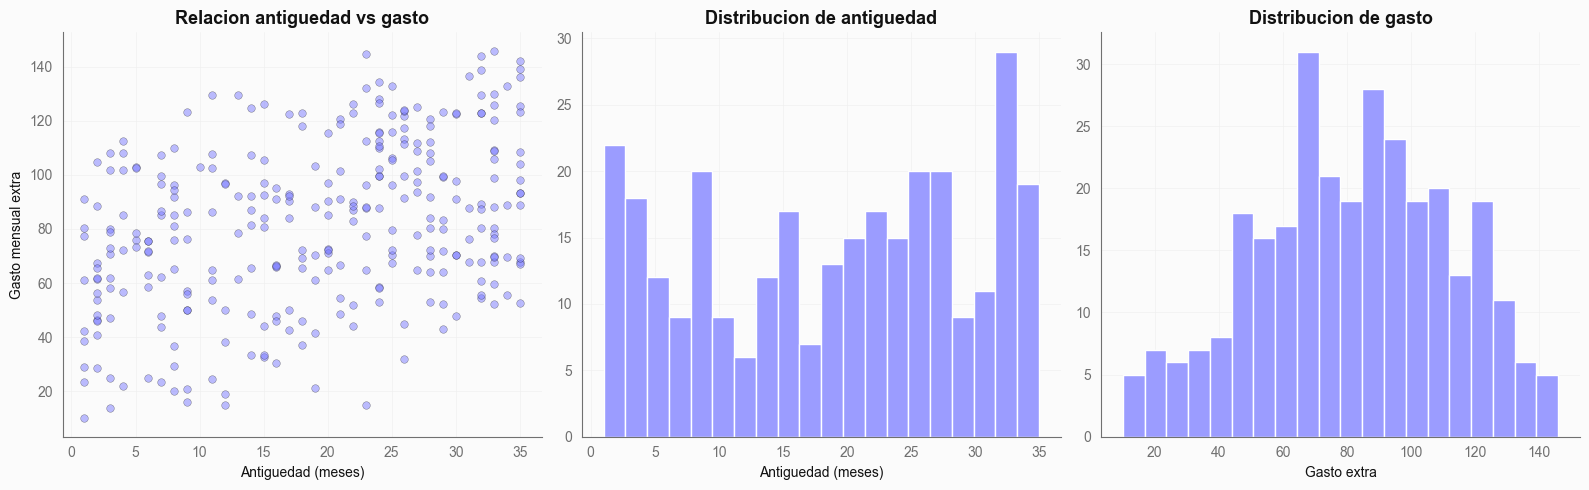

Correlacion Pearson: 0.384


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter
axes[0].scatter(df["Antiguedad_Meses"], df["Gasto_Mensual_Extra"], color=PURPLE, alpha=0.5, s=30, edgecolors="k", linewidths=0.3)
axes[0].set_xlabel("Antiguedad (meses)")
axes[0].set_ylabel("Gasto mensual extra")
axes[0].set_title("Relacion antiguedad vs gasto")

# Histograma antiguedad
axes[1].hist(df["Antiguedad_Meses"], bins=20, color=PURPLE_LIGHT, edgecolor="white")
axes[1].set_xlabel("Antiguedad (meses)")
axes[1].set_title("Distribucion de antiguedad")

# Histograma gasto
axes[2].hist(df["Gasto_Mensual_Extra"], bins=20, color=PURPLE_LIGHT, edgecolor="white")
axes[2].set_xlabel("Gasto extra")
axes[2].set_title("Distribucion de gasto")

plt.tight_layout()
plt.show()

corr = df["Antiguedad_Meses"].corr(df["Gasto_Mensual_Extra"])
print(f"Correlacion Pearson: {corr:.3f}")

## 3. Estandarizacion

Las dos variables tienen escalas diferentes (meses vs euros). Sin estandarizar, la variable con mayor rango domina la distancia euclidiana.

In [4]:
X = df[["Antiguedad_Meses", "Gasto_Mensual_Extra"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Antes de escalar:")
print(f"  Antiguedad  — media: {X[:, 0].mean():.1f}, std: {X[:, 0].std():.1f}")
print(f"  Gasto       — media: {X[:, 1].mean():.1f}, std: {X[:, 1].std():.1f}")
print(f"\nDespues de escalar:")
print(f"  Antiguedad  — media: {X_scaled[:, 0].mean():.4f}, std: {X_scaled[:, 0].std():.4f}")
print(f"  Gasto       — media: {X_scaled[:, 1].mean():.4f}, std: {X_scaled[:, 1].std():.4f}")

Antes de escalar:
  Antiguedad  — media: 18.9, std: 10.6
  Gasto       — media: 81.7, std: 30.4

Despues de escalar:
  Antiguedad  — media: 0.0000, std: 1.0000
  Gasto       — media: -0.0000, std: 1.0000


## 4. Dendrograma

Usamos metodo Ward (minimiza varianza intra-cluster) con distancia euclidiana.

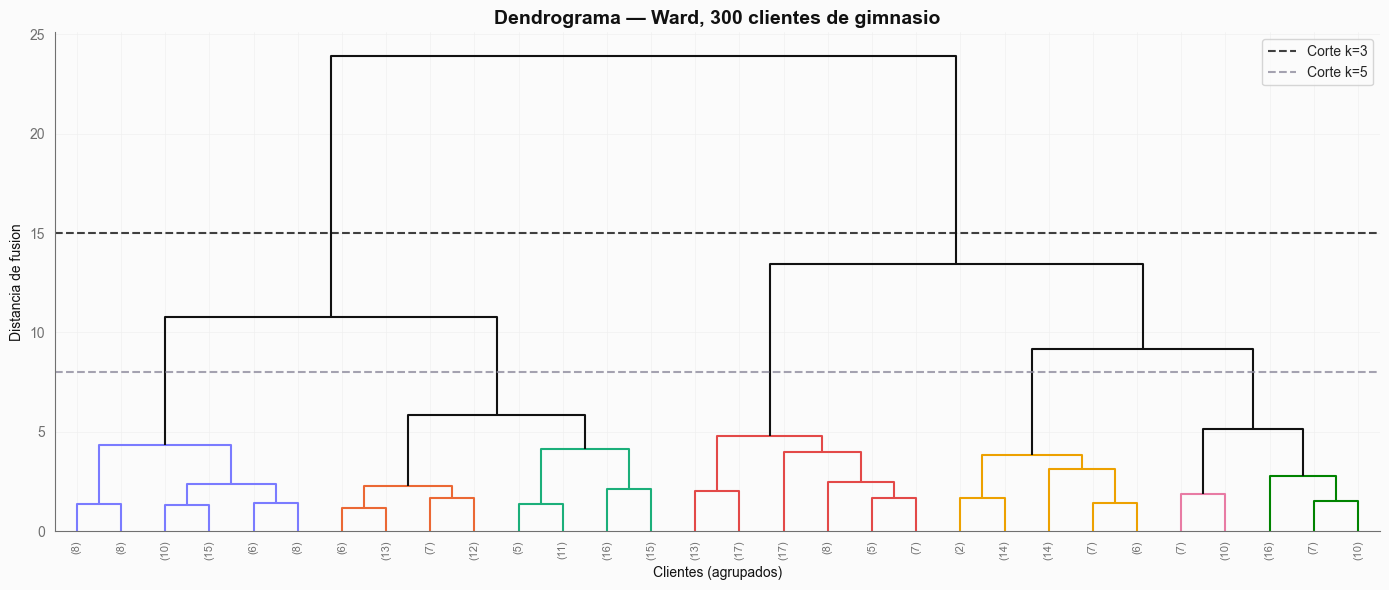

In [5]:
Z = linkage(X_scaled, method="ward", metric="euclidean")

set_link_color_palette(CLUSTER_PALETTE)

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=8,
           color_threshold=5, above_threshold_color=INK)
ax.set_title("Dendrograma — Ward, 300 clientes de gimnasio", fontsize=14, fontweight="bold")
ax.set_xlabel("Clientes (agrupados)")
ax.set_ylabel("Distancia de fusion")
ax.axhline(y=15, color=INK, linestyle="--", alpha=0.8, label="Corte k=3")
ax.axhline(y=8, color=NEUTRAL_LINE, linestyle="--", alpha=0.8, label="Corte k=5")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Seleccion del numero de clusters

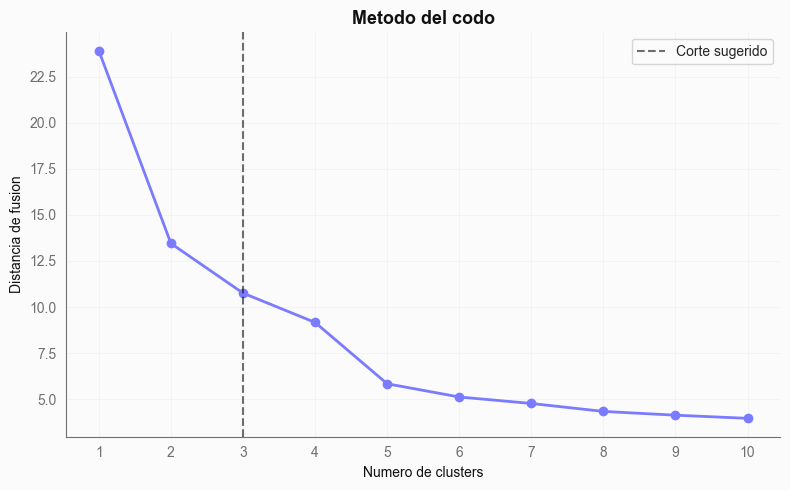

In [9]:
distancias = Z[:, 2]
ultimas = distancias[-10:][::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(ultimas) + 1), ultimas, marker="o", linewidth=2, color=PURPLE)
ax.set_xlabel("Numero de clusters")
ax.set_ylabel("Distancia de fusion")
ax.set_title("Metodo del codo")
ax.axvline(x=3, color=INK, linestyle="--", alpha=0.6, label="Corte sugerido")
ax.legend()
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.show()

## 6. Asignacion y visualizacion de clusters

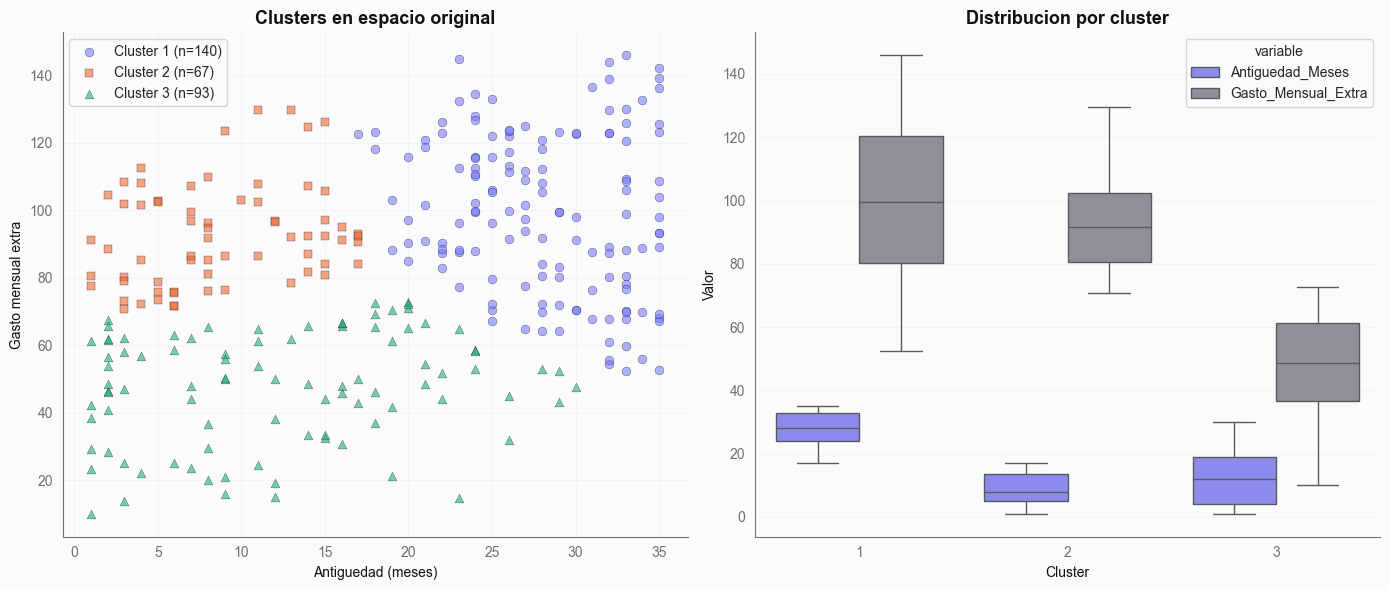

In [7]:
df["Cluster"] = fcluster(Z, t=3, criterion="maxclust")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sin escalar (espacio original)
for cl in sorted(df["Cluster"].unique()):
    sub = df[df["Cluster"] == cl]
    axes[0].scatter(sub["Antiguedad_Meses"], sub["Gasto_Mensual_Extra"],
                    s=40, alpha=0.6, label=f"Cluster {cl} (n={len(sub)})",
                    color=CLUSTER_PALETTE[(cl - 1) % len(CLUSTER_PALETTE)],
                    marker=CLUSTER_MARKERS[(cl - 1) % len(CLUSTER_MARKERS)],
                    edgecolors="k", linewidths=0.3)
axes[0].set_xlabel("Antiguedad (meses)")
axes[0].set_ylabel("Gasto mensual extra")
axes[0].set_title("Clusters en espacio original")
axes[0].legend()

# Boxplots por cluster
data_melt = df.melt(id_vars="Cluster", value_vars=["Antiguedad_Meses", "Gasto_Mensual_Extra"])
sns.boxplot(data=data_melt, x="Cluster", y="value", hue="variable", ax=axes[1],
            palette=[PURPLE, NEUTRAL_LINE])
axes[1].set_title("Distribucion por cluster")
axes[1].set_ylabel("Valor")

plt.tight_layout()
plt.show()

## 7. Perfil de cada cluster

In [8]:
perfil = df.groupby("Cluster").agg(
    n_clientes=("ID_Cliente", "count"),
    antiguedad_media=("Antiguedad_Meses", "mean"),
    antiguedad_std=("Antiguedad_Meses", "std"),
    gasto_medio=("Gasto_Mensual_Extra", "mean"),
    gasto_std=("Gasto_Mensual_Extra", "std"),
    pct_abandono=("Abandono", "mean"),
    pct_satisfecho=("Satisfecho", "mean")
).round(2)

perfil["pct_abandono"] = (perfil["pct_abandono"] * 100).round(1)
perfil["pct_satisfecho"] = (perfil["pct_satisfecho"] * 100).round(1)

print("Perfil de cada cluster:")
display(perfil)

print("\nInterpretacion:")
for cl in sorted(df["Cluster"].unique()):
    sub = df[df["Cluster"] == cl]
    print(f"  Cluster {cl}: {len(sub)} clientes, "
          f"antiguedad {sub['Antiguedad_Meses'].mean():.0f} meses, "
          f"gasto {sub['Gasto_Mensual_Extra'].mean():.0f} euros, "
          f"abandono {sub['Abandono'].mean()*100:.0f}%")

Perfil de cada cluster:


,n_clientes,antiguedad_media,antiguedad_std,gasto_medio,gasto_std,pct_abandono,pct_satisfecho
Cluster,,,,,,,
1,140,28.08,4.81,99.25,23.56,6.0,56.0
2,67,8.79,4.84,92.62,14.89,0.0,79.0
3,93,12.30,8.19,47.37,16.51,44.0,14.0



Interpretacion:
  Cluster 1: 140 clientes, antiguedad 28 meses, gasto 99 euros, abandono 6%
  Cluster 2: 67 clientes, antiguedad 9 meses, gasto 93 euros, abandono 0%
  Cluster 3: 93 clientes, antiguedad 12 meses, gasto 47 euros, abandono 44%


## 8. Conclusiones y recomendaciones

**Hallazgos:**
- Con solo 2 variables (antiguedad y gasto), el clustering jerarquico separa perfiles de cliente diferenciados.
- La estandarizacion es imprescindible: sin ella, la variable con mayor rango domina la segmentacion.
- El dendrograma permite explorar la estructura a distintos niveles de granularidad.

**Recomendaciones para el gimnasio:**
- Cruzar los clusters con tasas de abandono y satisfaccion permite priorizar acciones de retencion por segmento.
- Los socios de bajo gasto y baja antiguedad son candidatos a campanas de activacion temprana.